## Access this Notebook
You can launch this notebook in the US GHG Center JupyterHub (requires access) by clicking the following link: [**Carbon Dioxide and Methane Concentrations from the Los Angeles Megacity Carbon Project**](https://hub.ghg.center/hub/user-redirect/git-pull?repo=https%3A%2F%2Fgithub.com%2FUS-GHG-Center%2Fghgc-docs&urlpath=lab%2Ftree%2Fghgc-docs%2Fuser_data_notebooks%2Flam-testbed-ghg-concentrations_User_Notebook.ipynb&branch=main). If you are a new user, you should first sign up for the hub by filling out this [**request form**](https://docs.google.com/forms/d/e/1FAIpQLSdai8otCdrVQzJgev8mjDhzKyCg7jcrB3UeTXNHoCiaMKrkaQ/viewform) and providing the required information.

## Table of Contents
- [Data Summary and Application](#data-summary-and-application)
- [Approach](#approach)
- [About the Data](#about-the-data)
- [Terminology](#terminology)
- [Install the Required Libraries](#install-the-required-libraries)
- [Querying the Feature Vector API](#querying-the-feature-vector-api)
- [Time-Series Analysis](#time-series-analysis)
- [Summary](#summary)

## Data Summary and Application
- **Spatial coverage**: California’s South Coast Air Basin (includes urbanized portions of Los Angeles, Orange, Riverside, and San Bernardino counties)
- **Spatial resolution**: Point location samples
- **Temporal extent**: January 1, 2015 - January 31, 2025
- **Temporal resolution**: Hourly averages
- **Units**: Micromoles per mole of dry air (Parts CO₂ per million (ppm)); Nanomoles per mole of dry air (Parts CH₄ per billion (ppb))
- **Utility**: Climate Research

For more information, visit the [Carbon Dioxide and Methane Concentrations from the Los Angeles Megacity Carbon Project](https://earth.gov/ghgcenter/data-catalog/lam-testbed-ghg-concentrations) data overview page.

## Approach

1. Identify available dates and temporal frequency of observations for the given data. The collection processed in this notebook is the Carbon Dioxide and Methane Concentrations from the Los Angeles Megacity Carbon Project dataset.
2. Create a time-series analysis.

   

## About the Data

NIST is engaged in research to improve measurement of greenhouse gas emissions in areas containing multiple emission sources and sinks, such as cities. NIST's objective is to develop measurement tools supporting independent means to increase the accuracy of greenhouse gas emissions data at urban and regional geospatial scales. NIST has established three test beds in U.S. cities to develop and evaluate the performance of advanced measurement capabilities for emissions independent of their origin. Located in Indianapolis, Indiana, the Los Angeles air basin of California, and the U.S. Northeast corridor (beginning with the Baltimore/Washington D.C. region), the test beds have been selected for their varying meteorological, terrain, and emissions characteristics. These test beds will serve as a means to independently diagnose the accuracy of emissions data obtained directly from emission or uptake sources.

For more information regarding this dataset, please visit the [Carbon Dioxide and Methane Concentrations from the Los Angeles Megacity Carbon Project](https://earth.gov/ghgcenter/data-catalog/lam-testbed-ghg-concentrations) data overview page.

## Terminology
Navigating data via the US Greenhouse Gas Center (GHGC) Application Programming Interface (API), you will encounter terminology that is different from browsing in a typical filesystem. We'll define some terms here which are used throughout this notebook.

-  `collection`: A specific dataset, e.g. Carbon Dioxide and Methane Concentrations from the Los Angeles Megacity Carbon Project
-  `item`:       One file (i.e. granule) in the dataset, e.g. a file containing hourly CO₂ concentrations for a specific site

## Install the Required Libraries
Required libraries are pre-installed on the US GHG Center Hub. If you need to run this notebook elsewhere, please install them with this line in a code cell:

%pip install requests folium rasterstats pystac_client pandas matplotlib --quiet

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

## Querying the Feature Vector API
First, we are going to fetch the data using the US GHG Center Feature Vector Application Programming Interface (API). The provided endpoints refer to a location within the API that execute a request on a data files nesting on the server.

In [2]:
FEATURE_API_URL="https://earth.gov/ghgcenter/api/features"

In [3]:
# Function to fetch CSV data for a station with a limit parameter
def get_station_data_csv(station_code, gas_type, frequency, elevation_m, limit=100000):
    # Use the ?f=csv and limit query to get more rows
    url = f"https://earth.gov/ghgcenter/api/features/collections/public.nist_testbed_lam_{station_code}_{gas_type}_{frequency}_concentrations/items?f=csv&elevation_m={elevation_m}&limit={limit}"
    print(url)
    try:
        response = requests.get(url)
        
        # Check if the response is successful
        if response.status_code != 200:
            print(f"Failed to fetch data for {station_code}. Status code: {response.status_code}")
            return pd.DataFrame()

        # Check if the content type is CSV
        content_type = response.headers.get('Content-Type')
        if 'text/csv' not in content_type:
            print(f"Unexpected content type for {station_code}: {content_type}")
            print("Response content:", response.text)
            return pd.DataFrame()

        # Read the CSV content into a pandas DataFrame
        csv_data = StringIO(response.text)
        return pd.read_csv(csv_data)
    
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
        return pd.DataFrame()

## Time-Series Analysis
In the next cell, we'll plot hourly CO₂ concentrations for two LAM stations. The "SCI" station is on San Clemente Island, Los Angeles, CA, and the "COM" station is in Compton, Los Angeles, CA.

https://earth.gov/ghgcenter/api/features/collections/public.nist_testbed_lam_sci_co2_hourly_concentrations/items?f=csv&elevation_m=489&limit=10000
https://earth.gov/ghgcenter/api/features/collections/public.nist_testbed_lam_com_co2_hourly_concentrations/items?f=csv&elevation_m=9&limit=10000


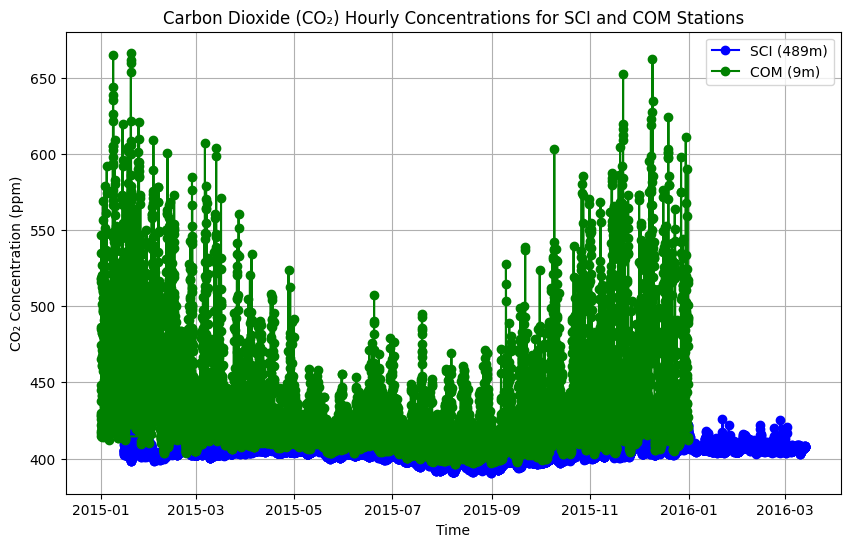

In [ ]:
# Get station name and elevation from metdata dataframe
# Fetch data for SCI (elevation 489) and COM (elevation 9), using limit=10000
# ch4/co2 to select the ghg 

sci_data = get_station_data_csv('sci', 'co2', 'hourly', 489, limit=10000)
com_data = get_station_data_csv('com', 'co2', 'hourly', 9, limit=10000)

# Check if data was successfully retrieved before proceeding
if sci_data.empty or com_data.empty:
    print("No data available for one or both stations. Exiting.")
else:
    # Convert the 'datetime' column to datetime for plotting
    sci_data['datetime'] = pd.to_datetime(sci_data['datetime'], format='%Y-%m-%dT%H:%M:%SZ')
    com_data['datetime'] = pd.to_datetime(com_data['datetime'], format='%Y-%m-%dT%H:%M:%SZ')

    # Plot the data
    plt.figure(figsize=(10, 6))
    plt.plot(sci_data['datetime'], sci_data['value'], label='SCI (489m)', color='blue', marker='o')
    plt.plot(com_data['datetime'], com_data['value'], label='COM (9m)', color='green', marker='o')

    plt.title('Carbon Dioxide (CO₂) Hourly Concentrations for SCI and COM Stations')
    plt.xlabel('Time')
    plt.ylabel('CO₂ Concentration (ppm)')
    plt.legend()
    plt.grid(True)

    # Show plot
    plt.show()

## Summary
In this notebook, we have successfully completed the following steps for the Carbon Dioxide and Methane Concentrations from the Los Angeles Megacity Carbon Project dataset:

1.  Install and import the necessary libraries
2.  Fetch the data using the US GHG Center Feature Vector API
3.  Plot a time series of hourly CO₂ concentrations for two LAM sites

If you have any questions regarding this user notebook, please contact us using the [feedback form](https://docs.google.com/forms/d/e/1FAIpQLSeVWCrnca08Gt_qoWYjTo6gnj1BEGL4NCUC9VEiQnXA02gzVQ/viewform).